# Healthcare Analytics: Length of Stay (LOS) & Billing Analysis

**Author:** Mert Can YALÇIN  
**Domain:** Healthcare Informatics & Data Analytics  
**Objective:** Explore Length of Stay (LOS) and Billing Amount using data cleaning, visualization, and statistical analysis.

In [1]:
# Import the main libraries used in the analysis.
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/prasad22/healthcare-dataset/healthcare_dataset.csv")

# Take a first look at the data
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Dataset Overview

The dataset contains patient records with demographic, clinical, admission, insurance, and billing information.

The original dataset contains **55,500 records and 15 variables**. In this project, the main focus is on **Length of Stay** and **Billing Amount**, while other variables are used to explore possible patterns in the data.

### Data Source

The dataset was obtained from Kaggle:

**Healthcare Dataset**  
[https://www.kaggle.com/datasets/prasad22/healthcare-dataset](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)

### Dataset Limitation

The dataset shows highly balanced distributions across several variables. This may limit the ability to identify strong relationships between variables.


In [2]:
# Dataset Overview
# Check the dataset size, column names, data types, and missing values.

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

df.info()

Dataset shape: (55500, 15)

Column names:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-n

In [3]:
# Missing Value Analysis
# Check each column for missing values before starting the data cleaning process.
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Missing Values

No missing values were found in the dataset, so no missing-value treatment was required.

In [4]:
# Duplicate Record Analysis

# Check for duplicated rows to ensure that each record appears only once.
df.duplicated().sum()

# Examine duplicated rows before deciding whether they should be removed.
df[df.duplicated()]

# Calculate the number of records remaining after removing duplicate rows.
df.shape[0]- df.duplicated().sum()

# Remove duplicated rows while keeping the first occurrence of each record.
df = df.drop_duplicates()

# Verify that no duplicate rows remain after data cleaning.
df.duplicated().sum()

np.int64(0)

### Duplicate Records

A total of **534 exact duplicate records** were identified in the dataset.

Since these rows were identical across all available variables, they were removed to avoid counting the same record multiple times.

The dataset size decreased from **55,500 to 54,966 records** after duplicate removal.

In [5]:
# Standardize name formatting for consistency.
df["Name"] = df["Name"].str.title()

# Verify the standardized name format.
df["Name"].head()

0    Bobby Jackson
1     Leslie Terry
2      Danny Smith
3     Andrew Watts
4    Adrienne Bell
Name: Name, dtype: object

### Text Standardization

Some names had inconsistent capitalization. The `Name` column was standardized using title case for consistency.

In [6]:
# Data Type Conversion
# Convert date columns to datetime format.
df["Discharge Date"]= pd.to_datetime(df["Discharge Date"])
df["Date of Admission"]=pd.to_datetime(df["Date of Admission"])

# Check the data types after conversion.
df[["Date of Admission" ,"Discharge Date"]].dtypes


Date of Admission    datetime64[ns]
Discharge Date       datetime64[ns]
dtype: object

### Date Conversion

The admission and discharge date columns were converted to datetime format so that the length of each hospital stay could be calculated.

In [7]:
# Feature Engineering: Length of Stay
# Calculate the number of days each patient stayed in the hospital.
df["Length of Stay"]= (df["Discharge Date"] - df["Date of Admission"]).dt.days

# Display the first five Length of Stay values.
df["Length of Stay"].head()


0     2
1     6
2    15
3    30
4    20
Name: Length of Stay, dtype: int64

### Length of Stay

Length of Stay was calculated from the difference between the discharge date and admission date.

### Research Question

How is Length of Stay distributed in the dataset, and are there noticeable differences across Admission Type groups?

In [8]:
# Descriptive Statistics: Length of Stay
# Summarize the central tendency and distribution of hospital length of stay.

df["Length of Stay"].describe()

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

### Length of Stay Distribution

Length of Stay ranges from **1 to 30 days**, with a mean of approximately **15.5 days** and a median of **15 days**.

The values are distributed fairly evenly across this range.

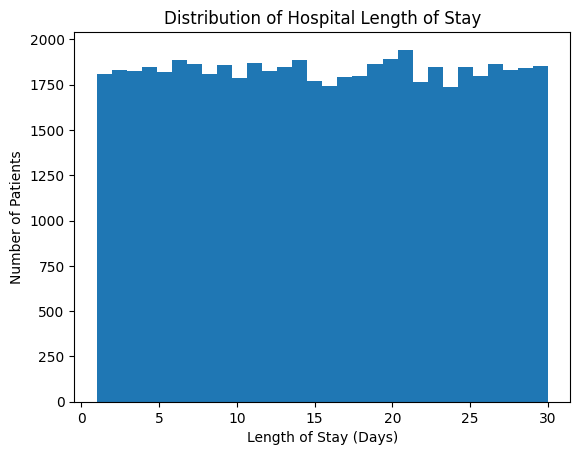

In [9]:
# Length of Stay Distribution
# Visualize the distribution of hospital length of stay across patients.

plt.hist(df["Length of Stay"],bins=30)
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Hospital Length of Stay")
plt.show()

### Interpretation

The Length of Stay values appear to be fairly evenly distributed across the 1–30 day range.

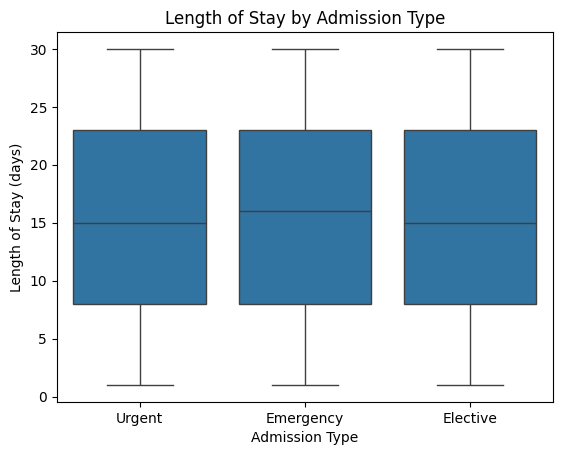

In [10]:
# Length of Stay by Admission Type
# Compare average hospital length of stay across different admission types.
df.groupby("Admission Type")["Length of Stay"].mean()

# Distribution of Length of Stay by Admission Type
# Compare the distribution of hospital stay duration across admission types.
sns.boxplot(data=df, x="Admission Type", y="Length of Stay")
plt.title("Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Length of Stay (days)")
plt.show()

### Interpretation


The boxplot shows that Length of Stay is quite similar across Urgent, Emergency, and Elective admissions. The median is around 15–16 days in all three groups, while the middle 50% of observations generally falls between 8 and 23 days. There are also no obvious outliers in any of the groups.

In [11]:
from scipy.stats import f_oneway

# Compare the mean Length of Stay across Admission Type groups.
anova_result = f_oneway(
    df[df["Admission Type"]== "Elective"]["Length of Stay"],
    df[df["Admission Type"]== "Urgent"]["Length of Stay"],
    df[df["Admission Type"]== "Emergency"]["Length of Stay"]
)

anova_result



F_onewayResult(statistic=np.float64(2.002699088101801), pvalue=np.float64(0.13498034295991865))

### ANOVA

A one-way ANOVA was performed to examine if mean Length of Stay differs among the three Admission Type groups.

The test resulted in a p-value of 0.135, which is above the 0.05 significance level. This indicates that there is no statistically significant evidence of a difference in mean Length of Stay among the three groups.

In [12]:
from scipy.stats import levene
# Check if the group variances are similar.
levene_result= levene(
    df[df["Admission Type"]== "Elective"]["Length of Stay"],
    df[df["Admission Type"]=="Urgent"]["Length of Stay"],
    df[df["Admission Type"]== "Emergency"]["Length of Stay"]

)
levene_result

LeveneResult(statistic=np.float64(0.8696444069916353), pvalue=np.float64(0.4191063186476759))

### Levene's Test

Levene's test was performed to check if the variance of Length of Stay is similar across the Admission Type groups.

The p-value was **0.419**, which is above the **0.05** significance level. This suggests that there is no statistically significant evidence of unequal variances between the groups.


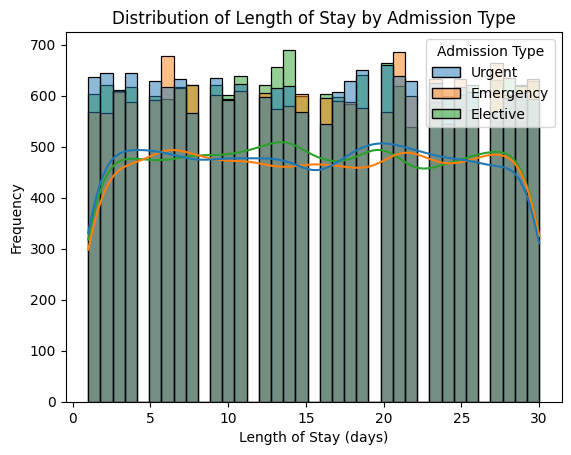

In [13]:


# Visualize the distribution of Length of Stay by admission type.
sns.histplot(
    data=df,
    x="Length of Stay",
    hue="Admission Type",
    kde=True
)
plt.title("Distribution of Length of Stay by Admission Type")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Frequency")
plt.show()


### Interpretation


The distribution of Length of Stay is fairly similar across the three admission types (Urgent, Emergency, and Elective). The frequencies are generally similar across most days, and the KDE curves also show similar patterns for all three groups. Overall, there is no clear visual difference in Length of Stay between the admission types.


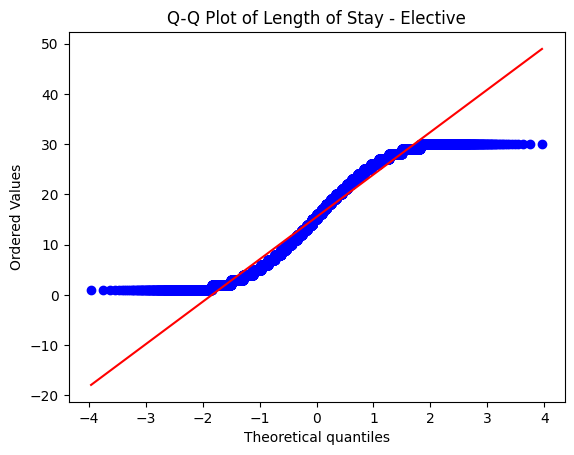

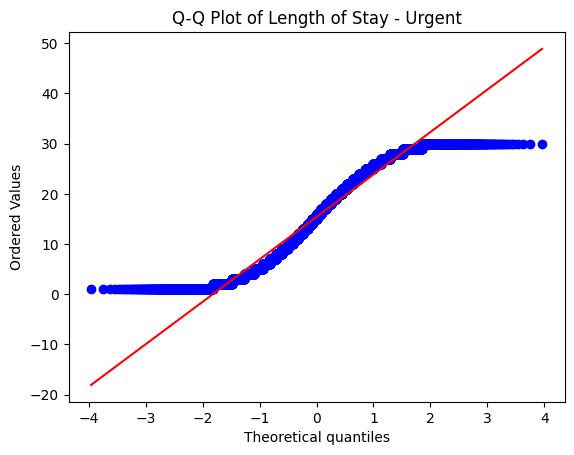

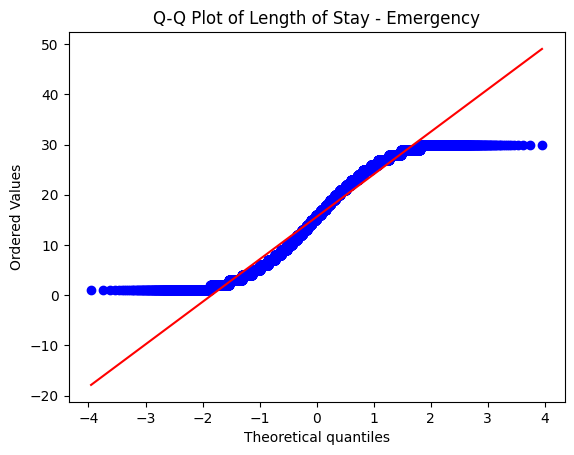

In [14]:
import scipy.stats as stats

# Create Q-Q plots to assess the normality of Length of Stay by admission type.

# Q-Q plot for Elective admissions.
stats.probplot(
    df[df["Admission Type"] == "Elective"]["Length of Stay"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Length of Stay - Elective")
plt.show()


# Q-Q plot for Urgent admissions.
stats.probplot(
    df[df["Admission Type"] == "Urgent"]["Length of Stay"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Length of Stay - Urgent")
plt.show()


# Q-Q plot for Emergency admissions.
stats.probplot(
    df[df["Admission Type"] == "Emergency"]["Length of Stay"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Length of Stay - Emergency")
plt.show()

### Q-Q Plot Interpretation

The Q-Q plots show a similar pattern for Elective, Urgent, and Emergency admissions. The points do not closely follow the reference line, particularly toward the two tails, suggesting that Length of Stay does not follow a normal distribution within these groups.

Since the normality assumption is not fully satisfied, the ANOVA results should be interpreted carefully. For an additional check, a non-parametric test is also used to compare Length of Stay across the three admission types.

In [15]:
from scipy.stats import kruskal

# Test whether Length of Stay differs across admission types using a non-parametric test.
kruskal_result = kruskal(
    df[df["Admission Type"]== "Elective"]["Length of Stay"],
    df[df["Admission Type"]== "Urgent"]["Length of Stay"],
    df[df["Admission Type"]== "Emergency"]["Length of Stay"]
    
)
kruskal_result

KruskalResult(statistic=np.float64(4.031048118289378), pvalue=np.float64(0.13325055389361784))

## Admission Type and Length of Stay

### Research Question

Does Length of Stay differ significantly across Admission Type groups?

### Statistical Analysis

The relationship between Admission Type and Length of Stay was examined using both parametric and non-parametric methods.

ANOVA was initially conducted to compare the mean Length of Stay across Admission Type groups. The test produced a p-value of **0.135**, which is greater than the significance level of **0.05**. Therefore, no statistically significant difference in mean Length of Stay was detected among the groups.

Levene's test was also conducted to assess the equality of variances. The p-value was **0.419**, indicating no statistically significant evidence of unequal variances.

As a non-parametric alternative, the Kruskal-Wallis test was conducted. The test produced a p-value of **0.133**, which is greater than **0.05**. Therefore, no statistically significant difference in Length of Stay was detected across the Admission Type groups.

### Conclusion

Overall, The results did not show a statistically significant difference in Length of Stay across the Admission Type groups.

In [16]:
# Descriptive statistics for Billing Amount
# Summarize the central tendency and distribution of billing amounts.
df["Billing Amount"].describe()

count    54966.000000
mean     25544.306284
std      14208.409711
min      -2008.492140
25%      13243.718641
50%      25542.749145
75%      37819.858159
max      52764.276736
Name: Billing Amount, dtype: float64

### Data Quality Check

The descriptive statistics show that the minimum Billing Amount is **-2,008.49**. Since a negative billing amount may not be expected in this dataset, these records should be examined before further analysis.

In [17]:
df[df["Billing Amount"]< 0]
df["Billing Amount"].lt(0).sum()
(df["Billing Amount"].lt(0).sum() / len(df)) * 100

np.float64(0.1928464869191864)

In [18]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [19]:
# Check insurance providers among negative billing records.
df[df["Billing Amount"] < 0]["Insurance Provider"].value_counts()

# Check admission types among negative billing records.
df[df["Billing Amount"] < 0]["Admission Type"].value_counts()

# Check doctors among negative billing records.
df[df["Billing Amount"]<0]["Doctor"].value_counts()

# Examine the distribution of negative billing amounts.
df[df["Billing Amount"] < 0]["Billing Amount"].describe()

count     106.000000
mean     -502.472497
std       429.857027
min     -2008.492140
25%      -803.004972
50%      -374.840042
75%      -149.074654
max       -23.866729
Name: Billing Amount, dtype: float64

### Data Quality Check

The descriptive statistics showed that the minimum Billing Amount was **-2,008.49**. Since negative billing amounts may not be valid for the intended billing analysis, these records were investigated before further analysis.

A total of **106 negative Billing Amount records** were identified, representing approximately **0.19%** of the dataset. These records were observed across different insurance providers, admission types, and doctors rather than being concentrated in a single category.

Based on this data quality assessment, negative Billing Amount records were excluded from the subsequent billing analysis.

In [20]:
# Keep non-negative billing amounts for the billing analysis.
df_billing = df[df["Billing Amount"] >= 0].copy()

# Verify that no negative billing amounts remain.
df_billing["Billing Amount"].lt(0).sum()

# Recalculate descriptive statistics after data cleaning.
df_billing["Billing Amount"].describe()

count    54860.000000
mean     25594.633637
std      14175.867041
min          9.238787
25%      13299.747940
50%      25593.873000
75%      37847.066671
max      52764.276736
Name: Billing Amount, dtype: float64

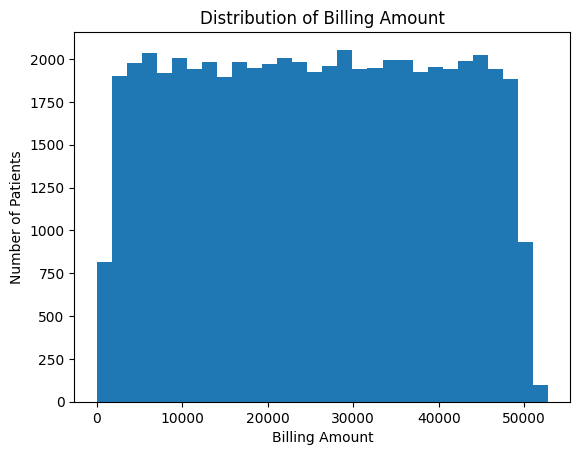

In [21]:
# Visualize the distribution of Billing Amount.
plt.hist(df_billing["Billing Amount"], bins=30)
plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.title("Distribution of Billing Amount")
plt.show()

In [22]:
df_billing["Billing Amount"].skew()

np.float64(2.900861791427602e-05)

### Billing Amount Distribution

The Billing Amount distribution was examined using a histogram. The values are spread across a wide range, with relatively similar frequencies across most of the observed range. Unlike a normal distribution, the histogram does not show a clear bell-shaped pattern with a central peak.

The skewness value was approximately **0.00003**, indicating that the distribution has almost no noticeable skewness.

Overall, the histogram appears relatively uniform across most of the observed range. However, this visual pattern alone is not sufficient to conclude that the data follows a uniform distribution.

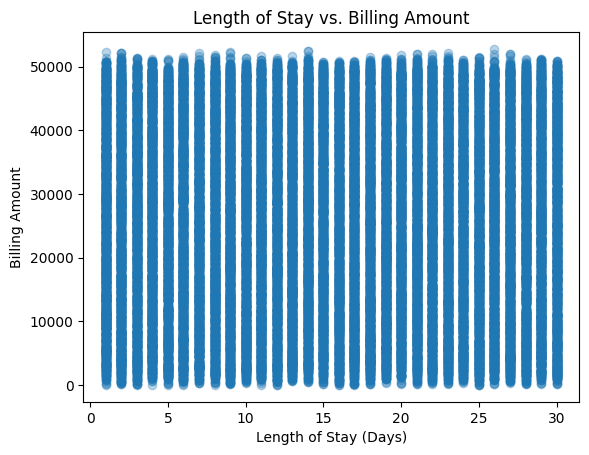

In [23]:
plt.scatter(df_billing["Length of Stay"],df_billing["Billing Amount"],alpha=0.3)
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Billing Amount")
plt.title("Length of Stay vs. Billing Amount")
plt.show()


### Relationship Between Length of Stay and Billing Amount

The scatter plot shows that Billing Amount values are widely distributed across different Length of Stay values. No clear upward or downward pattern is visually apparent, suggesting that there may not be a strong linear relationship between Length of Stay and Billing Amount.

In [24]:
df_billing["Length of Stay"].corr(df_billing["Billing Amount"])

# Test the strength and statistical significance of the linear relationship.
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df_billing["Length of Stay"],
    df_billing["Billing Amount"]
)

print("Pearson correlation:", correlation)
print("p-value:", p_value)

Pearson correlation: -0.004800992285179226
p-value: 0.2608096907426501


### Pearson Correlation Analysis

Pearson correlation was used to measure the strength and direction of the linear relationship between Length of Stay and Billing Amount.

The Pearson correlation coefficient was **-0.0048**, indicating an extremely weak linear association.

The p-value was **0.261**, which is greater than the significance level of **0.05**. Therefore, no statistically significant linear association was detected between Length of Stay and Billing Amount in this dataset.

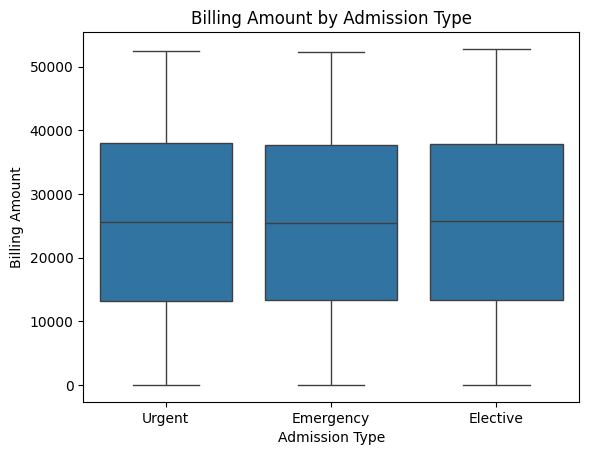

In [25]:
df_billing.groupby("Admission Type")["Billing Amount"].mean()

# Visualize Billing Amount distribution across Admission Type groups.
sns.boxplot(data=df_billing, x="Admission Type", y="Billing Amount")
plt.xlabel("Admission Type")
plt.ylabel("Billing Amount")
plt.title("Billing Amount by Admission Type")
plt.show()


### Billing Amount by Admission Type

The boxplot shows that the Billing Amount distributions are similar across the three Admission Type groups. The median values and overall spread appear to be relatively close across groups.

However, visual inspection alone is not sufficient to determine whether the differences between the groups are statistically significant. Therefore, an ANOVA test will be conducted to formally compare the group means.

In [26]:
from scipy.stats import f_oneway

# Test whether the mean Billing Amount differs across Admission Type groups.
anova_result = f_oneway(
    df_billing[df_billing["Admission Type"] == "Elective"]["Billing Amount"],
    df_billing[df_billing["Admission Type"] == "Emergency"]["Billing Amount"],
    df_billing[df_billing["Admission Type"] == "Urgent"]["Billing Amount"]
)

anova_result


F_onewayResult(statistic=np.float64(0.3329615790700373), pvalue=np.float64(0.7167991822829858))

### Billing Amount Analysis Summary

The analysis did not identify a statistically significant linear association between Length of Stay and Billing Amount. The Pearson correlation was **-0.0048**, with a p-value of **0.261**.

Billing Amount also did not differ significantly across Admission Type groups. The ANOVA test gave a p-value of **0.717**, which is greater than **0.05**.

Overall, the analysis did not provide enough evidence of a significant relationship between Billing Amount and the variables examined.

# Final Discussion

## Key Findings

This project examined Length of Stay (LOS) and Billing Amount using exploratory data analysis, visualization, and statistical testing.

No statistically significant difference in Length of Stay was found across the Admission Type groups. The ANOVA test resulted in a p-value of **0.135**, while the Kruskal-Wallis test resulted in a p-value of **0.133**.

The relationship between Length of Stay and Billing Amount was also examined. The Pearson correlation coefficient was **-0.0048**, with a p-value of **0.261**. This indicates that no statistically significant linear association was detected between the two variables.

Billing Amount was further compared across Admission Type and Insurance Provider groups. The corresponding ANOVA tests resulted in p-values of **0.717** and **0.821**, providing no statistically significant evidence of differences between the groups.

Overall, the analysis did not provide strong statistical evidence for the relationships examined in this dataset.

## Dataset Characteristics

The dataset contains several variables with relatively balanced category distributions. For example, the Admission Type and Medical Condition groups contain similar numbers of observations. Length of Stay is also distributed across the full 1–30 day range rather than being concentrated within a narrow interval.

These characteristics are important when interpreting the statistical results. The relatively balanced structure of several variables may reduce the extent of observable differences between groups.

However, the lack of statistically significant relationships should not be attributed to the dataset structure alone. Other characteristics of the data may also contribute to the observed results.

## Limitations

The main limitation of this analysis is the structure and scope of the dataset. Although it contains a relatively large number of observations, some variables have highly balanced distributions that may differ from patterns found in real-world healthcare data.

The analysis is also limited to the variables available in the dataset. Important factors that may influence hospital stay or billing, such as treatment complexity, procedures, hospital resources, and patient severity, are not included.

In addition, the statistical tests used in this project identify associations or differences within the available data. They do not establish causal relationships.

# Final Conclusion

This project applied data cleaning, feature engineering, exploratory data analysis, visualization, and statistical testing to examine Length of Stay and Billing Amount.

The statistical analyses did not identify significant differences or strong relationships among the main variables examined. These findings indicate that the available variables did not provide strong statistical evidence for the relationships investigated in this dataset.

The results also demonstrate the importance of considering the characteristics and limitations of a dataset when interpreting statistical findings. In this project, the absence of statistically significant relationships is itself an informative finding because it shows the importance of testing relationships rather than assuming that they exist.